In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("sales_data.csv")

In [3]:
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB


In [5]:
df.isnull().sum()

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].mean()
)

In [7]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df['Region'] = df['Region'].str.title()

In [11]:
df.columns = df.columns.str.strip()

In [12]:
for col in categorical_cols:
    df[col] = df[col].str.strip()

In [13]:
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])

In [14]:
summary = df.describe()

print(summary)

        Product_ID                      Sale_Date  Sales_Amount  \
count  1000.000000                           1000   1000.000000   
mean   1050.128000  2023-07-02 17:42:43.199999744   5019.265230   
min    1001.000000            2023-01-01 00:00:00    100.120000   
25%    1024.000000            2023-03-30 00:00:00   2550.297500   
50%    1051.000000            2023-06-30 12:00:00   5019.300000   
75%    1075.000000            2023-10-12 00:00:00   7507.445000   
max    1100.000000            2024-01-01 00:00:00   9989.040000   
std      29.573505                            NaN   2846.790126   

       Quantity_Sold    Unit_Cost   Unit_Price    Discount  
count    1000.000000  1000.000000  1000.000000  1000.00000  
mean       25.355000  2475.304550  2728.440120     0.15239  
min         1.000000    60.280000   167.120000     0.00000  
25%        13.000000  1238.380000  1509.085000     0.08000  
50%        25.000000  2467.235000  2696.400000     0.15000  
75%        38.000000  3702.865

In [15]:
total_sales = df['Sales_Amount'].sum()

print("Total Sales:", total_sales)

Total Sales: 5019265.2299999995


In [16]:
total_orders = len(df)

print("Total Orders:", total_orders)

Total Orders: 1000


In [17]:
avg_sales = df['Sales_Amount'].mean()

print("Average Sales:", avg_sales)

Average Sales: 5019.265229999999


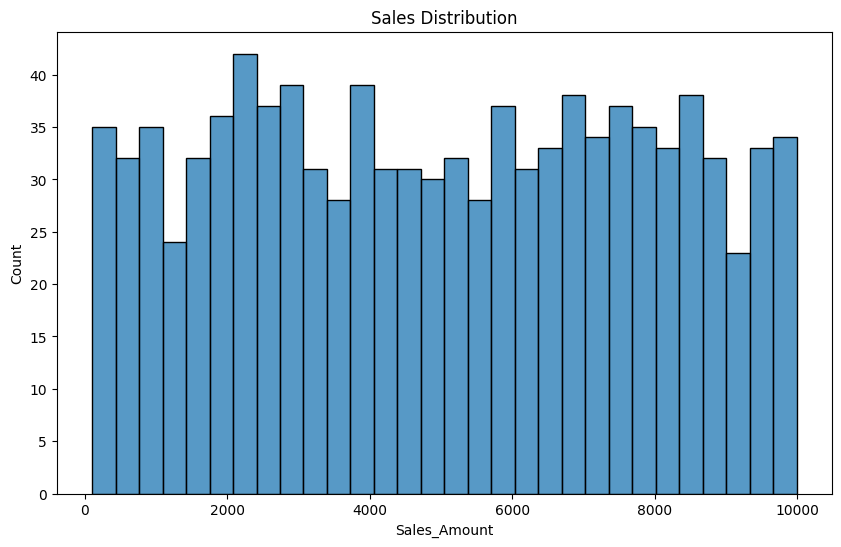

In [18]:
plt.figure(figsize=(10,6))

sns.histplot(df['Sales_Amount'], bins=30)

plt.title("Sales Distribution")

plt.show()

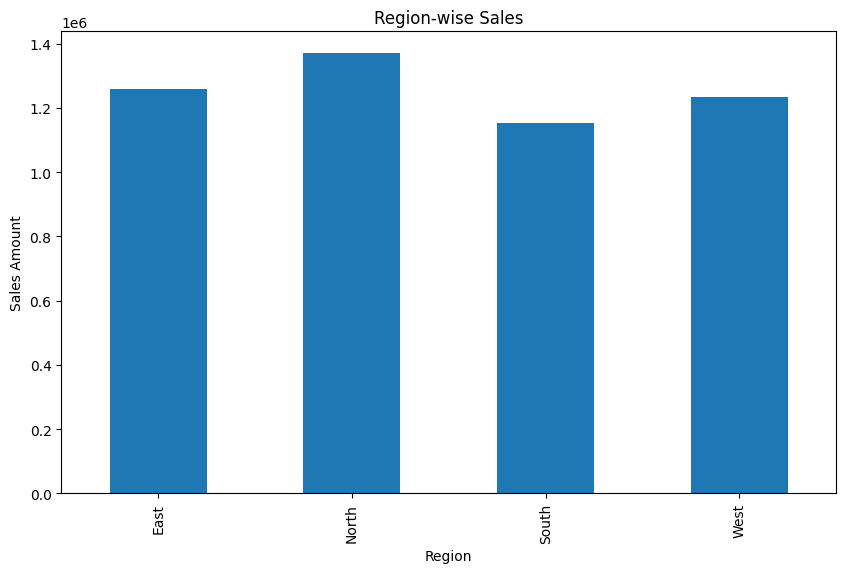

In [19]:
region_sales = df.groupby('Region')['Sales_Amount'].sum()

region_sales.plot(kind='bar', figsize=(10,6))

plt.title("Region-wise Sales")

plt.ylabel("Sales Amount")

plt.show()

In [20]:
df['Month'] = df['Sale_Date'].dt.month

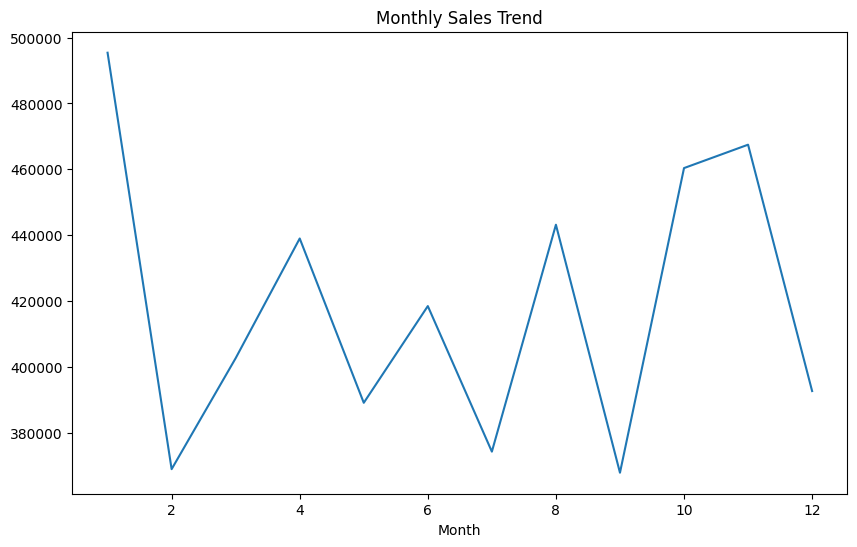

In [21]:
monthly_sales = df.groupby('Month')['Sales_Amount'].sum()

monthly_sales.plot(figsize=(10,6))

plt.title("Monthly Sales Trend")

plt.show()

In [22]:
from scipy.stats import zscore

z_scores = zscore(df['Sales_Amount'])

outliers = df[np.abs(z_scores) > 3]

print(outliers)

Empty DataFrame
Columns: [Product_ID, Sale_Date, Sales_Rep, Region, Sales_Amount, Quantity_Sold, Product_Category, Unit_Cost, Unit_Price, Customer_Type, Discount, Payment_Method, Sales_Channel, Region_and_Sales_Rep, Month]
Index: []


In [23]:
df.to_csv("cleaned_sales_data.csv", index=False)

In [24]:
with pd.ExcelWriter(
    'sales_report.xlsx',
    engine='openpyxl'
) as writer:

    df.to_excel(writer, sheet_name='Cleaned_Data', index=False)

    summary.to_excel(writer, sheet_name='Summary')